In [1]:
import warnings

import agama
import astropy
import gc_utils
import gizmo_analysis as gizmo
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import utilities as ut
from matplotlib.colors import LogNorm, Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy import stats
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from sklearn.svm import SVC

agama.setUnits(mass=1, length=1, velocity=1)
units = agama.getUnits()

In [2]:
sim = "m12i"
sim_dir = "/Users/z5114326/Documents/simulations/"

ghost_file = f"{sim_dir}{sim}/{sim}_ghosts.hdf5"
ghost_data = h5py.File(ghost_file, "r")

in_situ_msk = True  # True for include in_situ
ex_situ_msk = False  # True for include ex_situ

snap = 600

In [3]:
fire_dir = sim_dir + sim + "/" + sim + "_res7100/"
part600 = gc_utils.open_snapshot(600, fire_dir, ["star", "dark"])

Retrieving Snapshot 600..................: 100%|████████████████████████████████████████████████████████████████████████| 1/1 [00:18<00:00, 18.42s/it]


In [4]:
it_id = "it000"
src_dat = ghost_data[it_id]["source"]

m_tfo = 10 ** src_dat["logm_tfor"][()]
m_tfo_ev = 0.55 * (10 ** src_dat["logm_tfor"][()])

m_tz0_log = src_dat["logm_tz0"][()]
m_tz0 = np.array([10**x if x != -1 else 0 for x in m_tz0_log])

ml = m_tfo_ev - m_tz0

smsk = src_dat["s_flag"][()] == 1
samsk = src_dat["sa_flag"][()] == 1
amsk = src_dat["grpid"][()] == 0
# origin = np.zeros(len(amsk))
# origin[~amsk] = 1

r = np.linalg.norm(src_dat["pxyz_snap600"][()], axis=1)

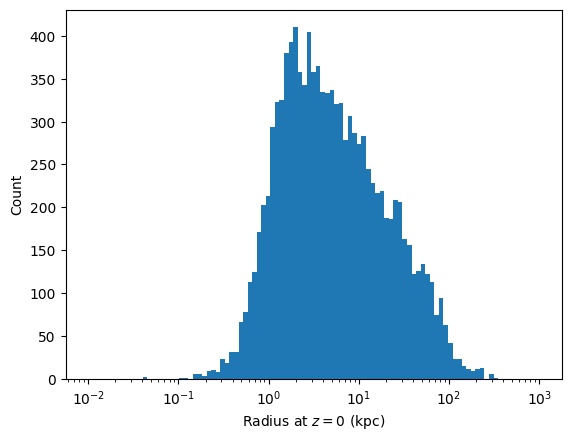

In [5]:
bins = np.logspace(-2, 3, 100)
plt.hist(r, bins=bins)

plt.xlabel(r"Radius at $z=0$ (kpc)")
plt.ylabel(r"Count")

plt.xscale("log")

In [6]:
data_dict = {"r": [], "ina": [], "ind": [], "exa": [], "exd_prea": [], "exd_posa": []}

for i in range(1, len(bins)):
    le = bins[i - 1]
    ue = bins[i]

    rmsk = (le <= r) & (r <= ue)

    data_dict["ina"].append(np.sum(ml[rmsk & amsk & smsk]))
    data_dict["ind"].append(np.sum(ml[rmsk & amsk & ~smsk]))

    data_dict["exa"].append(np.sum(ml[rmsk & ~amsk & smsk]))
    data_dict["exd_prea"].append(np.sum(ml[rmsk & ~amsk & ~smsk & ~samsk]))
    data_dict["exd_posa"].append(np.sum(ml[rmsk & ~amsk & ~smsk & samsk]))

    data_dict["r"].append(np.mean((le, ue)))  # WRONG

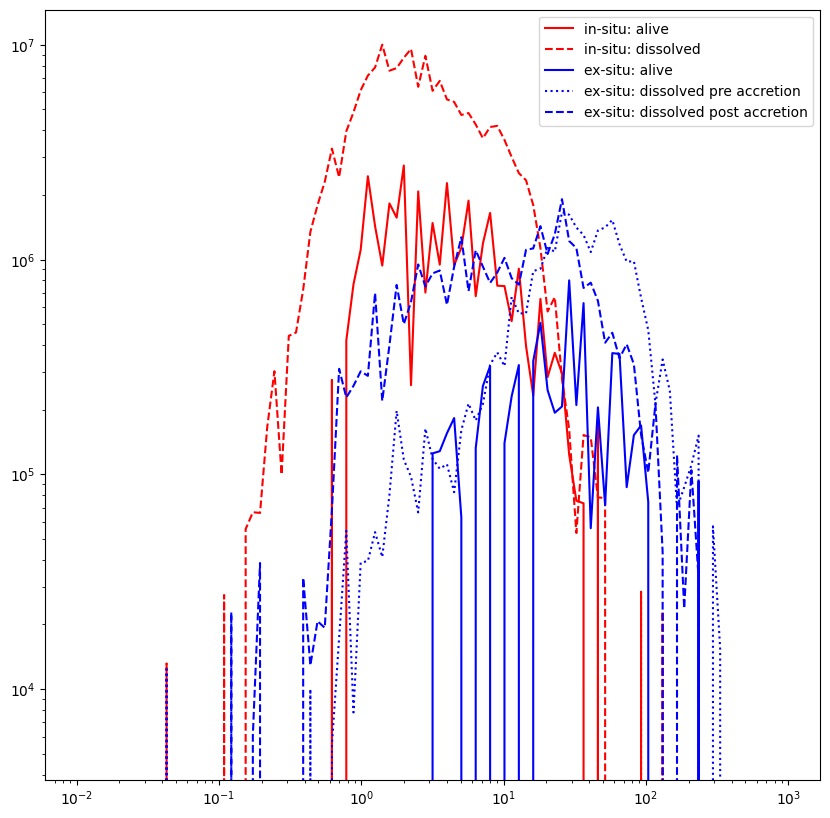

In [9]:
plt.figure(figsize=(10, 10))

plt.plot(data_dict["r"], data_dict["ina"], ls="-", c="r", label="in-situ: alive")
plt.plot(data_dict["r"], data_dict["ind"], ls="--", c="r", label="in-situ: dissolved")

plt.plot(data_dict["r"], data_dict["exa"], ls="-", c="b", label="ex-situ: alive")
plt.plot(data_dict["r"], data_dict["exd_prea"], ls=":", c="b", label="ex-situ: dissolved pre accretion")
plt.plot(data_dict["r"], data_dict["exd_posa"], ls="--", c="b", label="ex-situ: dissolved post accretion")


plt.xscale("log")
plt.yscale("log")

plt.legend()